In [7]:
# Empirical verification of Bessel's correction
import numpy as np

# 1. Generate a known population
np.random.seed(42)
population = np.random.normal(loc=50, scale=10, size=100_000)
true_variance = np.var(population)  # Population variance (divide by N)

# 2. Repeated random sampling
sample_size = 10
n_simulations = 10_000

var_without_correction = []  # ddof=0 (divide by n)
var_with_correction = []     # ddof=1 (divide by n - 1)

for _ in range(n_simulations):
    sample = np.random.choice(population, size=sample_size, replace=False)
    var_without_correction.append(np.var(sample, ddof=0))
    var_with_correction.append(np.var(sample, ddof=1))

# 3. Compare average sample variances against true variance
print(f"True Population Variance                   : {true_variance:.3f}")
print(f"Average Sample Variance (ddof=0, divide by n)  : {np.mean(var_without_correction):.3f}  (Biased / Underestimated)")
print(f"Average Sample Variance (ddof=1, divide by n-1): {np.mean(var_with_correction):.3f}  (Unbiased / Correct)")


True Population Variance                   : 100.180
Average Sample Variance (ddof=0, divide by n)  : 90.955  (Biased / Underestimated)
Average Sample Variance (ddof=1, divide by n-1): 101.061  (Unbiased / Correct)


# Homework 1: Welford's Algorithm (Numerically Stable Streaming Estimator)

### 1. The Problem with the Naive Formula (Catastrophic Cancellation)
The textbook algebraic identity for sample variance:
$$
s^2 = \frac{1}{n-1} \left( \sum_{i=1}^n x_i^2 - \frac{(\sum x_i)^2}{n} \right)
$$
In floating-point arithmetic (IEEE 754), if values are large with a small spread (e.g., $10^9 + 1, 10^9 + 2$), $\sum x_i^2$ and $(\sum x_i)^2/n$ are massive nearly-equal numbers. Subtracting them cancels out significant digits, yielding `0.0` or even negative variance.

### 2. Welford's Online Algorithm (1962)
Computes the mean and variance incrementally in a single pass ($O(1)$ memory):
- $n \leftarrow n + 1$
- $\delta_1 = x - \bar{x}_{old}$
- $\bar{x}_{new} \leftarrow \bar{x}_{old} + \frac{\delta_1}{n}$
- $\delta_2 = x - \bar{x}_{new}$
- $M_2 \leftarrow M_2 + \delta_1 \cdot \delta_2$
- Sample Variance (Bessel corrected): $s^2 = \frac{M_2}{n - 1}$ for $n > 1$


In [8]:
import math
import numpy as np

class WelfordEstimator:
    """
    Numerically stable online / streaming estimator for Mean, Variance, and Std Dev
    using Welford's Algorithm (1962).
    """
    def __init__(self):
        self.count = 0
        self.mean = 0.0
        self.M2 = 0.0  # Sum of squared deviations from the running mean

    def update(self, x: float):
        """Consume a single streaming observation."""
        self.count += 1
        delta = x - self.mean
        self.mean += delta / self.count
        delta2 = x - self.mean
        self.M2 += delta * delta2

    @property
    def sample_variance(self) -> float:
        """Sample variance s^2 with Bessel's correction (ddof=1)."""
        return self.M2 / (self.count - 1) if self.count > 1 else 0.0

    @property
    def population_variance(self) -> float:
        """Population variance sigma^2 (ddof=0)."""
        return self.M2 / self.count if self.count > 0 else 0.0

    @property
    def sample_std(self) -> float:
        """Sample standard deviation s (ddof=1)."""
        return math.sqrt(self.sample_variance)


In [9]:
# Experiment 1: Proof of Numerical Stability (Catastrophic Cancellation Test)
# Dataset: large numbers with small variance
# True sample variance of [1, 2, 3, 4, 5] is 2.5
data = [1e9 + 1, 1e9 + 2, 1e9 + 3, 1e9 + 4, 1e9 + 5]

def naive_sample_variance(vals):
    n = len(vals)
    sum_x = sum(vals)
    sum_sq = sum(x**2 for x in vals)
    return (sum_sq - (sum_x**2) / n) / (n - 1)

welford = WelfordEstimator()
for val in data:
    welford.update(val)

print(f"Data points: {data}\n")
print(f"NumPy Reference (ddof=1) : {np.var(data, ddof=1)}")
print(f"Naive Formula Result    : {naive_sample_variance(data):.4f}  <-- Catastrophic Cancellation (Failed)")
print(f"Welford Result          : {welford.sample_variance:.4f}  <-- Numerically Stable (Exact)")


Data points: [1000000001.0, 1000000002.0, 1000000003.0, 1000000004.0, 1000000005.0]

NumPy Reference (ddof=1) : 2.5
Naive Formula Result    : 0.0000  <-- Catastrophic Cancellation (Failed)
Welford Result          : 2.5000  <-- Numerically Stable (Exact)


In [10]:
# Experiment 2: Streaming Simulation (100,000 observations)
np.random.seed(42)
stream = np.random.normal(loc=100.0, scale=15.0, size=100_000)

online_estimator = WelfordEstimator()
for point in stream:
    online_estimator.update(point)

print("--- Streaming Verification Against NumPy ---")
print(f"NumPy Mean                  : {np.mean(stream):.6f}")
print(f"Welford Streaming Mean      : {online_estimator.mean:.6f}")
print()
print(f"NumPy Sample Std (ddof=1)   : {np.std(stream, ddof=1):.6f}")
print(f"Welford Sample Std (ddof=1) : {online_estimator.sample_std:.6f}")
print()
print(f"Absolute Difference         : {abs(np.std(stream, ddof=1) - online_estimator.sample_std):.2e}")


--- Streaming Verification Against NumPy ---
NumPy Mean                  : 100.014503
Welford Streaming Mean      : 100.014503

NumPy Sample Std (ddof=1)   : 15.013589
Welford Sample Std (ddof=1) : 15.013589

Absolute Difference         : 2.84e-14


# Homework 2: Percentage vs. Percentile & Rank Analysis

### Problem Statement
- **Total Students ($N$):** 100
- **Student's Score:** 85 out of 100
- **Students scoring < 85:** 90
- **Students scoring > 85:** 9
- **Students scoring = 85:** $100 - (90 + 9) = 1$

---

### Core Formulas
1. **Percentage (Absolute Score):**
   $$
   \text{Percentage} = \frac{\text{Marks Scored}}{\text{Total Marks}} \times 100 = \frac{85}{100} \times 100 = 85.0\%
   $$
2. **Percentile (Relative Standing):**
   $$
   \text{Percentile} = \frac{\text{Number of students with score } < 85}{\text{Total students}} \times 100 = \frac{90}{100} \times 100 = 90.0^{\text{th}}\text{ Percentile}
   $$
3. **Rank from Top:**
   $$
   \text{Rank} = \text{Students scoring } > 85 + 1 = 9 + 1 = 10^{\text{th}}\text{ Rank}
   $$


In [ ]:
# Homework 2: Percentage vs. Percentile & Rank
import numpy as np
from scipy import stats

# 1. Create student scores using list comprehension
# 90 scored < 85, 1 scored 85, 9 scored > 85
stud_scores = [70 for _ in range(90)] + [85] + [92 for _ in range(9)]
target_score = 85
total_marks = 100

# -------------------------------------------------------------
# 1. Pure Python Function (List Comprehension)
# -------------------------------------------------------------
def percentile_python(scores, score):
    less_scores = [s for s in scores if s < score]
    return (len(less_scores) / len(scores)) * 100

pr_python = percentile_python(stud_scores, target_score)

# -------------------------------------------------------------
# 2. Inbuilt NumPy
# Note: np.percentile(a, q) takes percentile q (0-100) -> returns score (inverse)
# To find percentile rank of a score in NumPy, use vectorized boolean mean:
pr_numpy = np.mean(np.array(stud_scores) < target_score) * 100

# -------------------------------------------------------------
# 3. Inbuilt SciPy Function (scipy.stats.percentileofscore)
# -------------------------------------------------------------
pr_scipy = stats.percentileofscore(stud_scores, target_score, kind='strict')

# -------------------------------------------------------------
# Display Summary
# -------------------------------------------------------------
percentage = (target_score / total_marks) * 100
rank = len([s for s in stud_scores if s > target_score]) + 1

print(f"Percentage                        : {percentage:.2f}%")
print(f"Class Rank                        : {rank}th rank from top (out of {len(stud_scores)} students)")
print("-" * 68)
print(f"Method 1: Pure Python (List Comp) : {pr_python:.2f}th percentileb")
print(f"Method 2: Inbuilt NumPy (np.mean) : {pr_numpy:.2f}th percentile")
print(f"Method 3: Inbuilt SciPy Function  : {pr_scipy:.2f}th percentile")


Percentage                        : 85.00%
Class Rank                        : 10th rank from top (out of 100 students)
--------------------------------------------------------------------
Method 1: Pure Python (List Comp) : 90.00th percentile
Method 2: Inbuilt NumPy (np.mean) : 90.00th percentile
Method 3: Inbuilt SciPy Function  : 90.00th percentile


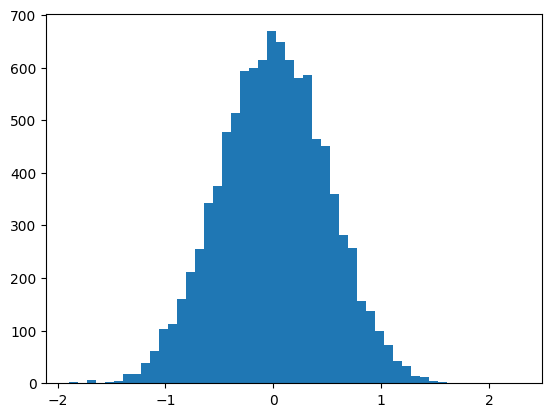

array([-0.42561264,  0.0021952 ,  0.64240076])

In [18]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0, 0.5, 10000)

plt.hist(data, bins=50)
plt.show()
np.percentile(data, [20, 50, 90])

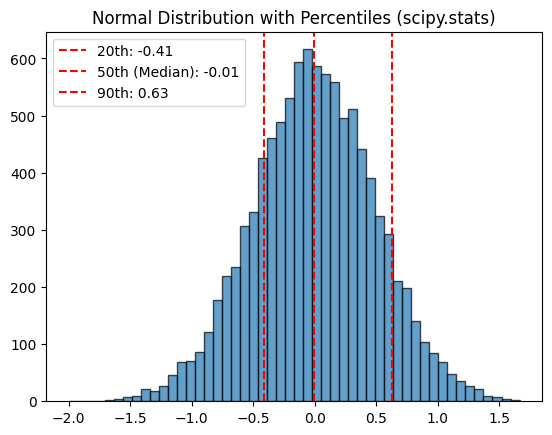

Sample Percentiles via stats.scoreatpercentile : [-0.41487066 -0.00540908  0.62879569]
Theoretical Percentiles via stats.norm.ppf       : [-0.42081062  0.          0.64077578]
NumPy Percentiles via np.percentile             : [-0.41487066 -0.00540908  0.62879569]


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Generate normal distribution data
data = np.random.normal(0, 0.5, 10000)

# 2. Calculate percentiles with scipy.stats
# stats.scoreatpercentile is the scipy equivalent of np.percentile
p_scipy = stats.scoreatpercentile(data, [20, 50, 90])

# (Optional) Theoretical percentiles from the normal distribution using PPF (Percent Point Function)
p_theoretical = stats.norm.ppf([0.20, 0.50, 0.90], loc=0, scale=0.5)

# 3. Plot histogram with percentiles
plt.hist(data, bins=50, edgecolor='black', alpha=0.7)
for p, name in zip(p_scipy, ['20th', '50th (Median)', '90th']):
    plt.axvline(p, color='red', linestyle='--', linewidth=1.5, label=f"{name}: {p:.2f}")

plt.title("Normal Distribution with Percentiles (scipy.stats)")
plt.legend()
plt.show()

print("Sample Percentiles via stats.scoreatpercentile :", p_scipy)
print("Theoretical Percentiles via stats.norm.ppf       :", p_theoretical)
print("NumPy Percentiles via np.percentile             :", np.percentile(data, [20, 50, 90]))


# Interquartile Range (IQR) & Outlier Detection (Tukey's Fences)

### 1. Mathematical Definitions
- **First Quartile ($Q_1$ / $25^{\text{th}}$ percentile):** Boundary separating the bottom 25% of data.
- **Second Quartile ($Q_2$ / Median / $50^{\text{th}}$ percentile):** Center of data.
- **Third Quartile ($Q_3$ / $75^{\text{th}}$ percentile):** Boundary separating the top 25% of data.
- **Interquartile Range (IQR):** Measures the spread of the central 50% (robust against outliers):
  $$\text{IQR} = Q_3 - Q_1$$

### 2. Outlier Detection with Tukey's Fences ($1.5 \times \text{IQR}$ Rule)
- **Lower Fence:** $Q_1 - 1.5 \times \text{IQR}$
- **Upper Fence:** $Q_3 + 1.5 \times \text{IQR}$
- Data points falling outside $[\text{Lower Fence}, \text{Upper Fence}]$ are classified as **outliers**.


            INTERQUARTILE RANGE (IQR) SUMMARY              
Q1 (25th Percentile)       : -0.3407
Median (50th Percentile)   : 0.0022
Q3 (75th Percentile)       : 0.3414
IQR (NumPy: Q3 - Q1)       : 0.6820
IQR (SciPy: stats.iqr)     : 0.6820
------------------------------------------------------------
Lower Fence (Q1 - 1.5*IQR) : -1.3637
Upper Fence (Q3 + 1.5*IQR) : 1.3644
Outliers Count             : 43 out of 10000 (0.43%)


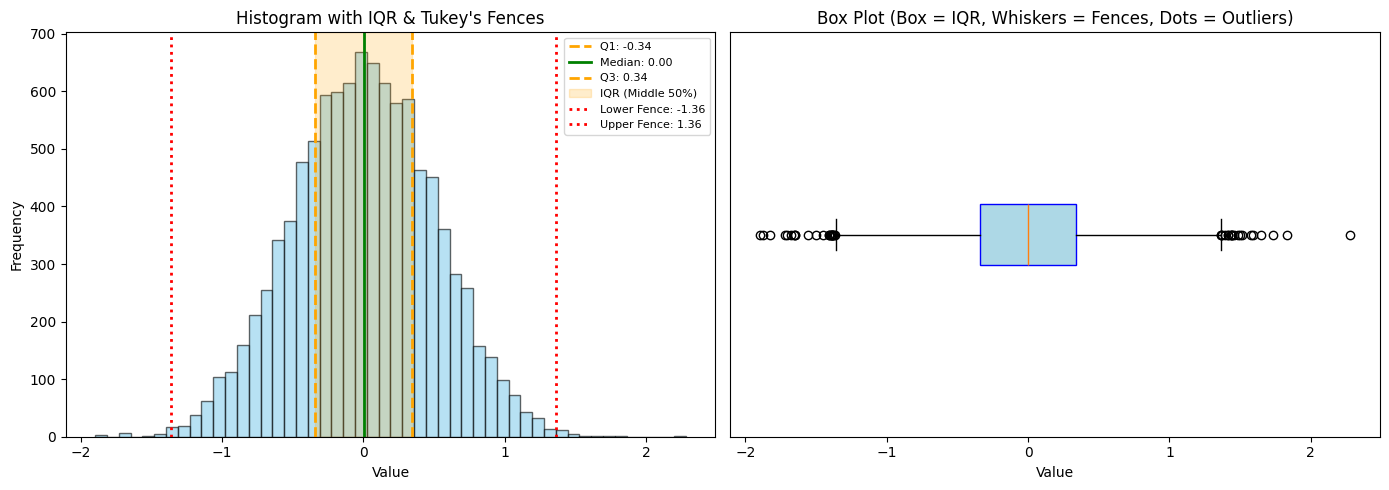

In [ ]:
# ==============================================================================
# Interquartile Range (IQR), Median, and Outlier Detection (Tukey's Fences)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------------------------------------------------------------------
# Step 0: Ensure Data Availability
# ------------------------------------------------------------------------------
# If 'data' is not already generated in memory, create a random normal sample
# with Mean (mu) = 0, Standard Deviation (sigma) = 0.5, and size = 10,000 points.
if 'data' not in globals():
    data = np.random.normal(loc=0.0, scale=0.5, size=10000)

# Convert to a NumPy ndarray to support fast vectorized operations & boolean masking
data = np.asarray(data)

# ------------------------------------------------------------------------------
# Step 1: Compute Five-Number Summary & Measures of Central Tendency
# ------------------------------------------------------------------------------
# Minimum: The smallest observed value in the dataset
min_val = np.min(data)

# Q1 (First Quartile / 25th Percentile):
# 25% of the data points lie below this threshold (75% lie above).
q1 = np.percentile(data, 25)

# Median / Q2 (Second Quartile / 50th Percentile):
# The exact geometric middle of the ordered dataset. Unlike the Mean, 
# the Median is robust (resistant) to extreme values and heavy skewness.
median_val = np.median(data)

# Mean (Arithmetic Average):
# Sum of all values divided by N. Highly sensitive to extreme outliers.
mean_val = np.mean(data)

# Q3 (Third Quartile / 75th Percentile):
# 75% of the data points lie below this threshold (25% lie above).
q3 = np.percentile(data, 75)

# Maximum: The largest observed value in the dataset
max_val = np.max(data)

# ------------------------------------------------------------------------------
# Step 2: Dispersion Measures (IQR & Semi-IQR / Quartile Deviation)
# ------------------------------------------------------------------------------
# Interquartile Range (IQR):
# The distance between Q3 and Q1 (IQR = Q3 - Q1).
# It captures the spread of the middle 50% of the distribution.
iqr_numpy = q3 - q1

# Inbuilt SciPy Function:
# scipy.stats.iqr() computes the exact same interquartile range natively.
iqr_scipy = stats.iqr(data)

# Semi-Interquartile Range (Quartile Deviation):
# Half of the IQR (IQR / 2). Used as a robust measure of spread around the median.
semi_iqr = iqr_numpy / 2.0

# ------------------------------------------------------------------------------
# Step 3: Outlier Detection via Tukey's Fences (1.5 * IQR Rule)
# ------------------------------------------------------------------------------
# John Tukey defined inner fences to classify outliers:
# - Lower Fence = Q1 - 1.5 * IQR (Values smaller than this are unusually low)
# - Upper Fence = Q3 + 1.5 * IQR (Values larger than this are unusually high)
lower_fence = q1 - 1.5 * iqr_numpy
upper_fence = q3 + 1.5 * iqr_numpy

# Vectorized Boolean Masking:
# (data < lower_fence) | (data > upper_fence) creates a boolean array of True/False,
# allowing us to extract all outlier points in a single vectorized step.
outliers = data[(data < lower_fence) | (data > upper_fence)]
outlier_pct = (len(outliers) / len(data)) * 100.0

# ------------------------------------------------------------------------------
# Step 4: Display Comprehensive Statistical Report
# ------------------------------------------------------------------------------
print("=" * 68)
print("     COMPREHENSIVE DESCRIPTIVE STATISTICS & IQR OUTLIER REPORT       ")
print("=" * 68)
print(f"Total Sample Size (N)             : {len(data)}")
print("-" * 68)
print("1. CENTRAL TENDENCY:")
print(f"   - Mean (Arithmetic Average)     : {mean_val:.4f}  (Sensitive to outliers)")
print(f"   - Median / Q2 (50th Percentile) : {median_val:.4f}  (Robust center)")
print(f"   - Difference |Mean - Median|    : {abs(mean_val - median_val):.4f}")
print("-" * 68)
print("2. FIVE-NUMBER SUMMARY:")
print(f"   - Minimum                       : {min_val:.4f}")
print(f"   - Q1 (25th Percentile)          : {q1:.4f}")
print(f"   - Median (50th Percentile)      : {median_val:.4f}")
print(f"   - Q3 (75th Percentile)          : {q3:.4f}")
print(f"   - Maximum                       : {max_val:.4f}")
print("-" * 68)
print("3. DISPERSION (IQR MEASURES):")
print(f"   - IQR (NumPy: Q3 - Q1)          : {iqr_numpy:.4f}  (Middle 50% spread)")
print(f"   - IQR (SciPy: stats.iqr)        : {iqr_scipy:.4f}")
print(f"   - Semi-IQR (Quartile Deviation) : {semi_iqr:.4f}")
print("-" * 68)
print("4. TUKEY'S OUTLIER DETECTION (1.5 * IQR RULE):")
print(f"   - Lower Fence (Q1 - 1.5*IQR)    : {lower_fence:.4f}")
print(f"   - Upper Fence (Q3 + 1.5*IQR)    : {upper_fence:.4f}")
print(f"   - Outliers Detected             : {len(outliers)} points ({outlier_pct:.2f}% of data)")
print("=" * 68)

# ------------------------------------------------------------------------------
# Step 5: Dual Visualization (Histogram with IQR Band + Box Plot)
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Plot 1: Histogram with Central Tendency, IQR Span, and Fences ---
ax1.hist(data, bins=50, edgecolor='black', alpha=0.6, color='skyblue', label='Sample Distribution')

# Vertical line for Q1 (25th percentile)
ax1.axvline(q1, color='orange', linestyle='--', linewidth=2, label=f'Q1 (25%): {q1:.2f}')

# Vertical line for Median (50th percentile)
ax1.axvline(median_val, color='green', linestyle='-', linewidth=2.5, label=f'Median (Q2): {median_val:.2f}')

# Vertical line for Mean (Arithmetic average)
ax1.axvline(mean_val, color='blue', linestyle='-.', linewidth=1.5, label=f'Mean: {mean_val:.2f}')

# Vertical line for Q3 (75th percentile)
ax1.axvline(q3, color='orange', linestyle='--', linewidth=2, label=f'Q3 (75%): {q3:.2f}')

# Shaded span highlighting the IQR (middle 50% of values)
ax1.axvspan(q1, q3, color='orange', alpha=0.2, label=f'IQR Region ({iqr_numpy:.2f})')

# Dotted lines marking the Tukey outlier boundaries
ax1.axvline(lower_fence, color='red', linestyle=':', linewidth=2, label=f'Lower Fence: {lower_fence:.2f}')
ax1.axvline(upper_fence, color='red', linestyle=':', linewidth=2, label=f'Upper Fence: {upper_fence:.2f}')

ax1.set_title("Histogram: Central Tendency, IQR Band & Fences", fontsize=11, fontweight='bold')
ax1.set_xlabel("Value")
ax1.set_ylabel("Frequency")
ax1.legend(loc='upper right', fontsize=8)

# --- Plot 2: Box Plot Illustrating the 5-Number Summary & Outliers ---
# The box represents the IQR (Q1 to Q3). The red line is the Median.
# The whiskers extend to the furthest non-outlier points (within 1.5 * IQR).
# Circular markers (fliers) beyond the whiskers represent individual outliers.
bp = ax2.boxplot(data, vert=False, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='navy', linewidth=1.5),
                 medianprops=dict(color='red', linewidth=2.5),
                 whiskerprops=dict(color='black', linestyle='--', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='darkred', markersize=5, alpha=0.6))

ax2.set_title("Box Plot: Five-Number Summary & Outliers", fontsize=11, fontweight='bold')
ax2.set_xlabel("Value")
ax2.set_yticks([])  # Hide y-axis ticks as this is a univariate box plot

# Annotate key metrics on the Box Plot for clarity
ax2.text(median_val, 1.15, f'Median: {median_val:.2f}', color='red', ha='center', fontweight='bold', fontsize=9)
ax2.text(q1, 0.75, f'Q1: {q1:.2f}', color='navy', ha='center', fontsize=8)
ax2.text(q3, 0.75, f'Q3: {q3:.2f}', color='navy', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# 1. IQR using NumPy Library
# ==============================================================================
import numpy as np

prices = [2, 3, 4, 5, 6, 7, 8]
median_numpy = np.median(prices)
q1_np = np.percentile(prices, 25)
q3_np = np.percentile(prices, 75)
iqr_numpy = q3_np - q1_np

print(f"Median using numpy : {median_numpy}")
print(f"Q1 (25th percentile): {q1_np}")
print(f"Q3 (75th percentile): {q3_np}")
print(f"IQR using numpy     : {iqr_numpy}")

# ==============================================================================
# 2. IQR using SciPy Library
# ==============================================================================
from scipy.stats import iqr

srt_price = sorted(prices)
IQR_scipy = iqr(srt_price)
print(f"\nIQR using scipy     : {IQR_scipy}")

# ==============================================================================
# 3. IQR Manually without Any Library
# ==============================================================================
def find_median(data):
    data_len = len(data)
    mid = data_len // 2
    # Check if length of data is even or odd
    if data_len % 2 == 0:
        return (data[mid] + data[mid - 1]) / 2.0
    return data[mid]

srt_price = sorted(prices)
manual_median = find_median(srt_price)
mid = len(srt_price) // 2

# Lower half (excluding median for odd N) and upper half
q1_manual = find_median(srt_price[:mid])
q3_manual = find_median(srt_price[mid + 1:])
iqr_manual = q3_manual - q1_manual

print(f"\nMedian manually     : {manual_median}")
print(f"Q1 manually         : {q1_manual}")
print(f"Q3 manually         : {q3_manual}")
print(f"IQR manually        : {iqr_manual}")


Median using numpy : 5.0
Q1 (25th percentile): 3.5
Q3 (75th percentile): 6.5
IQR using numpy     : 3.0

IQR using scipy     : 3.0

Median manually     : 5
Q1 manually         : 3
Q3 manually         : 7
IQR manually        : 4
